**Job Postings and Integration Context**

**Introduction**

We have 50,000 job ads stored in a file called job_postings.csv. Each ad has an ID, the date it was posted the 
location, company name, type of work and many other details. 

We want to use a tool called Apache Spark to load this data clean it and make it easier to understand. We will check 
the data for mistakes like missing information or duplicate job postings. 

The job_postings.csv file has job ads from 2020 to 2024. Each ad has 24 pieces of information like job title, industry, 
company size, location and salary range. We also have information about the company like its size and type of work. 

This notebook executes an ETL (Extract, Transform, Load) pipeline for job postings data using Apache Spark. The pipeline is intended to:
- **Ingest**: Loading the raw data from the csv file
- **Clean**: Validate the data such as removing bulls and duplicates
- **Integrate**: Splitting and transforming data such as skills into a structured format
- **Analyze**: Execute exploratory data analysis to identify key trends (eg: highest paying skills, salary trends, etc.)
- **Store**: Endure the cleaned and enhanced data for further use.

**What are the characteristics of the dataset?**

- **Job listing details**: title, industry, location, work_type, experience_level, education, skills
- **Salary analysis**: salary_minimum and salary_maximum, average_salary
- **Company information**: company_size
- **Application metrics**: days_to_fill, applicant_count
- **Categorizations**: seniority_level


Source: job_postings.csv

Github link:https://github.com/sifen2022-cpu/Data-Integration-.git


https://drive.google.com/file/d/1BnYQ36xUuXWLpj2gqsjjB52NqkeSsdEd/view?usp=sharing

Name: Sifen Dagne Semu

ID number: GH1029686

%md
**Section 1**: **Data Exploration and Understanding**

%md
**Data Loading - ETL/ELT Pipeline**

%md
In this part we load the data check its quality and look for missing information or duplicate job postings.

In [0]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np
import re
from collections import	Counter
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import (col, count, when, trim, lower, split, explode)

spark = SparkSession.builder.appName("JobPostingsETL").getOrCreate()

In [0]:
df = spark.read.csv("/Workspace/Users/sifen.semu@gisma-student.com/job_postings.csv", header=True, inferSchema=True)
print("Loaded:", df.count(), "rows,", len(df.columns), "columns")
display(df.limit(10))

def dq(df, label):
    m = {}
    m["total_rows"] = df.count()

    null_counts = df.select([
        count(when(col(c).isNull(), c)).alias(c)
        for c in ["salary_min", "education_required"]
    ]).collect()[0].asDict()
    m["null_salary_min"] = null_counts["salary_min"]
    m["null_education"] = null_counts["education_required"]

    m["salary_violations"] = df.filter(
        (col("salary_min") > col("salary_max")) | (col("salary_min") < 0)
    ).count()

    m["remote_contradictions"] = df.filter(
        (col("location") == "Remote") & (col("work_type") == "On-site")
    ).count()

    distinct_job_ids = df.select("job_id").distinct().count()
    m["duplicate_job_ids"] = m["total_rows"] - distinct_job_ids

    print(f"\n--- Data Quality Report: {label} ---")
    print(f"Total rows: {m['total_rows']}")
    print(f"Null values in 'salary_min': {m['null_salary_min']}")
    print(f"Null values in 'education_required': {m['null_education']}")
    print(f"Salary violations (salary_min > salary_max or salary_min < 0): {m['salary_violations']}")
    print(f"Remote contradictions (location='Remote' & work_type='On-site'): {m['remote_contradictions']}")
    print(f"Duplicate job IDs: {m['duplicate_job_ids']}\n")

    return m
    return m

Loaded: 50000 rows, 24 columns


job_id,post_date,year,month,job_title,industry,company,company_size,location,state,work_type,experience_level,experience_min_yrs,experience_max_yrs,education_required,salary_min,salary_max,salary_midpoint,skills_required,benefits,days_to_fill,applicant_count,seniority,is_tech_role
J0000001,2023-12-30,2023,12,Quantitative Analyst,Education,Summit Digital,Enterprise (5000+),Remote,Remote,On-site,Entry (0-2 yrs),0,2,Bachelor's,126000,153000,139000,Python|Financial Modeling|Derivatives,Dental/Vision|Stock Options|401k,29,41,Junior,0
J0000002,2022-05-25,2022,5,Backend Developer,Education,Nexus AI,Large (1001-5000),"Boston, MA",MA,On-site,Executive (15+ yrs),15,20,Bachelor's,297000,432000,362000,Redis|Docker|Python|Java|AWS,Health Insurance|Flexible Hours|Remote Work|Dental/Vision,20,88,Executive,0
J0000003,2020-09-08,2020,9,HR Manager,Consulting,Summit Corp,Mid-size (201-1000),"Atlanta, GA",GA,On-site,Senior (6-9 yrs),6,9,PhD,118000,157000,136000,Compensation|Talent Acquisition|Employment Law,Flexible Hours|Stock Options|Parental Leave,33,52,Senior,0
J0000004,2022-01-21,2022,1,Cloud Architect,Healthcare,Summit Systems,Large (1001-5000),"New York, NY",NY,Hybrid,Senior (6-9 yrs),6,9,Bachelor's,247000,359000,306000,Terraform|GCP|Microservices,401k|Learning Budget|Remote Work|Unlimited PTO|Stock Options,15,142,Senior,0
J0000005,2024-11-07,2024,11,Software Engineer,Manufacturing,Stellar Ventures,Large (1001-5000),"Washington, DC",DC,On-site,Mid (3-5 yrs),3,5,Master's,163000,218000,185000,Git|Kubernetes|Java|Docker|Python|REST APIs,Stock Options|Dental/Vision|Remote Work|Health Insurance,53,342,Mid,0
J0000006,2023-11-01,2023,11,Operations Manager,Logistics,Nexus Partners,Small (51-200),"Chicago, IL",IL,On-site,Lead (10-15 yrs),10,15,Bachelor's,145000,187000,167000,Lean|Budgeting|Process Improvement|ERP,Parental Leave|Flexible Hours|Unlimited PTO,24,93,Lead,0
J0000007,2020-06-09,2020,6,Quantitative Analyst,Government,Synergy AI,Startup (1-50),"Los Angeles, CA",CA,On-site,Senior (6-9 yrs),6,9,Bachelor's,166000,244000,204000,Statistics|R|Python|C++|Derivatives,Learning Budget|Dental/Vision|Gym Membership,12,111,Senior,0
J0000008,2023-09-15,2023,9,Quantitative Analyst,Government,Nova Technologies,Small (51-200),"New York, NY",NY,Hybrid,Mid (3-5 yrs),3,5,Master's,222000,319000,264000,Python|Derivatives|Risk Management|R|C++,401k|Unlimited PTO|Remote Work|Dental/Vision,23,120,Mid,0
J0000009,2024-03-15,2024,3,Senior Software Engineer,E-commerce,Apex Technologies,Mid-size (201-1000),"Phoenix, AZ",AZ,Hybrid,Mid (3-5 yrs),3,5,Bachelor's,134000,202000,169000,Java|Docker|AWS|Python|CI/CD,Gym Membership|Remote Work,23,127,Mid,0
J0000010,2023-09-30,2023,9,Data Engineer,Media,Stellar Technologies,Startup (1-50),"San Francisco, CA",CA,On-site,Entry (0-2 yrs),0,2,Master's,126000,159000,141000,dbt|Snowflake|AWS|Spark|Python,Flexible Hours|Parental Leave|Gym Membership|401k|Learning Budget,12,51,Junior,0


In [0]:
df.printSchema()

root
 |-- job_id: string (nullable = true)
 |-- post_date: date (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- job_title: string (nullable = true)
 |-- industry: string (nullable = true)
 |-- company: string (nullable = true)
 |-- company_size: string (nullable = true)
 |-- location: string (nullable = true)
 |-- state: string (nullable = true)
 |-- work_type: string (nullable = true)
 |-- experience_level: string (nullable = true)
 |-- experience_min_yrs: integer (nullable = true)
 |-- experience_max_yrs: integer (nullable = true)
 |-- education_required: string (nullable = true)
 |-- salary_min: integer (nullable = true)
 |-- salary_max: integer (nullable = true)
 |-- salary_midpoint: integer (nullable = true)
 |-- skills_required: string (nullable = true)
 |-- benefits: string (nullable = true)
 |-- days_to_fill: integer (nullable = true)
 |-- applicant_count: integer (nullable = true)
 |-- seniority: string (nullable = true)
 |-- i

Based on the schema print outfrom Apache Spark, we can group our 24 columns based on their data types.
- String: There are 13 string columns in our dataset which are job_id, job_title, industry, company, company_size, location, state, work_type, experience_level, education_required, skills_required, benefits, and seniority.

- Integer: There are 10 integer columns in our dataset which are year, month, experience_min_yrs, experience_max_yrs, salary_mix, salary_max, salary_midpoint, days_to_fill, is_tech_role, and applicant_count.

- Date: There is 1 date column in our dataset which is post_date.

In [0]:
from pyspark.sql.functions import col, count, when

total_rows = df.count()
missing_data = df.select([
    count(when(col(c).isNull(), c)).alias(c) for c in df.columns
]).collect()[0].asDict()

import pandas as pd

missing_summary = []
for col_name in df.columns:
    missing_count = missing_data[col_name]
    missing_percent = round((missing_count / total_rows) * 100, 1)
    missing_summary.append({
        'Column': col_name,
        'Missing Count': missing_count,
        'Missing %': missing_percent
    })

missing_df = pd.DataFrame(missing_summary)
print(f"{'Column':<20} {'Missing Count':<15} {'Missing %':<10}")
for _, row in missing_df.iterrows():
    print(f"{row['Column']:<20} {row['Missing Count']:<15} {row['Missing %']:<10}")

Column               Missing Count   Missing % 
job_id               0               0.0       
post_date            0               0.0       
year                 0               0.0       
month                0               0.0       
job_title            0               0.0       
industry             0               0.0       
company              0               0.0       
company_size         0               0.0       
location             0               0.0       
state                0               0.0       
work_type            0               0.0       
experience_level     0               0.0       
experience_min_yrs   0               0.0       
experience_max_yrs   0               0.0       
education_required   0               0.0       
salary_min           0               0.0       
salary_max           0               0.0       
salary_midpoint      0               0.0       
skills_required      0               0.0       
benefits             0               0.0

 
We calculate missing values in each column. Found no missing values. 
We also check for job postings and find none. 

In [0]:
print('Check for duplicates in original DataFrame')
dq_report_original = dq(df, "Original Data")
print(f"Number of duplicate job IDs in original DataFrame: {dq_report_original['duplicate_job_ids']}")

Check for duplicates in original DataFrame

--- Data Quality Report: Original Data ---
Total rows: 50000
Null values in 'salary_min': 0
Null values in 'education_required': 0
Salary violations (salary_min > salary_max or salary_min < 0): 0
Remote contradictions (location='Remote' & work_type='On-site'): 3313
Duplicate job IDs: 0

Number of duplicate job IDs in original DataFrame: 0


We have got 3313 duplicate rows in the "remote_contradiction" column whichh represents a mismatch between two attributes: location and work type. For these 3313 specific rows, the "location" is labeled as "remote", which contradicts the work type being labeled as "on-site".

**Section 2: Data Preprocessing and Cleaning**

**Data Cleaning and Quality Report Function**

In [0]:
from pyspark.sql.functions import when, col, trim

df_clean = df.withColumn(
    "work_type",
    when(col("location") == "Remote", "Remote").otherwise(col("work_type"))
)

columns_to_trim = [
    "job_id", "job_title", "industry", "company", 
    "company_size", "location", "state", "work_type", 
    "experience_level", "seniority"
]

df_clean = df_clean.withColumns({c: trim(col(c)) for c in columns_to_trim})

print("Cleaned:", df_clean.count(), "rows")
display(df_clean.limit(5))

Cleaned: 50000 rows


job_id,post_date,year,month,job_title,industry,company,company_size,location,state,work_type,experience_level,experience_min_yrs,experience_max_yrs,education_required,salary_min,salary_max,salary_midpoint,skills_required,benefits,days_to_fill,applicant_count,seniority,is_tech_role
J0000001,2023-12-30,2023,12,Quantitative Analyst,Education,Summit Digital,Enterprise (5000+),Remote,Remote,Remote,Entry (0-2 yrs),0,2,Bachelor's,126000,153000,139000,Python|Financial Modeling|Derivatives,Dental/Vision|Stock Options|401k,29,41,Junior,0
J0000002,2022-05-25,2022,5,Backend Developer,Education,Nexus AI,Large (1001-5000),"Boston, MA",MA,On-site,Executive (15+ yrs),15,20,Bachelor's,297000,432000,362000,Redis|Docker|Python|Java|AWS,Health Insurance|Flexible Hours|Remote Work|Dental/Vision,20,88,Executive,0
J0000003,2020-09-08,2020,9,HR Manager,Consulting,Summit Corp,Mid-size (201-1000),"Atlanta, GA",GA,On-site,Senior (6-9 yrs),6,9,PhD,118000,157000,136000,Compensation|Talent Acquisition|Employment Law,Flexible Hours|Stock Options|Parental Leave,33,52,Senior,0
J0000004,2022-01-21,2022,1,Cloud Architect,Healthcare,Summit Systems,Large (1001-5000),"New York, NY",NY,Hybrid,Senior (6-9 yrs),6,9,Bachelor's,247000,359000,306000,Terraform|GCP|Microservices,401k|Learning Budget|Remote Work|Unlimited PTO|Stock Options,15,142,Senior,0
J0000005,2024-11-07,2024,11,Software Engineer,Manufacturing,Stellar Ventures,Large (1001-5000),"Washington, DC",DC,On-site,Mid (3-5 yrs),3,5,Master's,163000,218000,185000,Git|Kubernetes|Java|Docker|Python|REST APIs,Stock Options|Dental/Vision|Remote Work|Health Insurance,53,342,Mid,0


%md
Now that we understand our dataset having 50,000 rows and 24 columns, with duplicate records but no missing values making it suitable for analysis. 

The Data Cleaning steps fulfilled are:
- Jobs with a 'Remote' location are changed to 'Remote' work typs.
- We removed whitespaces from text fields such as job_title, industry, company, location, company_size, state, work_type, experience_level, and seniority to confirm compactness.

Before Cleaning

We used a function called dq to check data quality before and after cleaning. The results showed that the data was 
clean and ready for analysis. 

In [0]:
def dq(df, label):
    m = {"total_rows": df.count()}
    nulls = df.select([count(when(col(c).isNull(), c)).alias(c)
                       for c in ["salary_min", "education_required"]]).collect()[0].asDict()
    m["null_salary_min"] = nulls["salary_min"]
    m["null_education"]  = nulls["education_required"]
    m["salary_violations"] = df.filter((col("salary_min") > col("salary_max")) | (col("salary_min") < 0)).count()
    m["remote_contradictions"] = df.filter((col("location") == "Remote") & (col("work_type") == "On-site")).count()
    m["duplicate_job_ids"] = m["total_rows"] - df.select("job_id").distinct().count()
    print(f"--- {label} ---")
    for k, v in m.items(): print(f"  {k:24s}: {v}")
    return m

dq(df, "BEFORE cleaning")

--- BEFORE cleaning ---
  total_rows              : 50000
  null_salary_min         : 0
  null_education          : 0
  salary_violations       : 0
  remote_contradictions   : 3313
  duplicate_job_ids       : 0


{'total_rows': 50000,
 'null_salary_min': 0,
 'null_education': 0,
 'salary_violations': 0,
 'remote_contradictions': 3313,
 'duplicate_job_ids': 0}

At this stage, the initial data quality report shows that the raw dataset was already clean. It has 50,000 rows without null values in salary_min and education, no salary violations, and no duplicate job_ids. 

The main issue we got was the 3313 remote contradictions where job postings had mixed the locations (remote) and work type (on-site).

After Cleaning



In [0]:
c = df

c = c.withColumn("work_type", when(col("location") == "Remote", "Remote").otherwise(col("work_type")))

for x in ["job_title", "industry", "company", "location"]:
    c = c.withColumn(x, trim(col(x)))

c = c.withColumn("industry", lower(col("industry")))

c = c.drop("salary_midpoint")

c = c.dropDuplicates(["job_id"])
c = c.na.drop(subset=["job_id", "salary_min", "salary_max"])

c = c.filter((col("salary_min") >= 0) & (col("salary_min") <= col("salary_max")))

df_clean = c
dq(df_clean, "AFTER cleaning")
print("Distinct industries:", df_clean.select("industry").distinct().count())

--- AFTER cleaning ---
  total_rows              : 50000
  null_salary_min         : 0
  null_education          : 0
  salary_violations       : 0
  remote_contradictions   : 0
  duplicate_job_ids       : 0
Distinct industries: 11


After cleaning and processing we had a dataset with 50,000 rows and 11 unique industries. We 
eliminated 3313 contradictions and standardized industry names.

**Section 3: Data Integration and Transformation**



Then we moved on to data integration and transformation. We took the skills required for each job split them into 
skills and created a table with job ID, industry and skill. 
We calculated the demand for each skill by counting its appearances. We joined this data with the skills table to 
create a table with skill frequency. 
 
Finally we saved the enriched data to tables. Created a temporary view of the postings data. We used this view to 
calculate the salary per industry and display the results. 

Transform Semi-Structured Skills

In [0]:
from pyspark.sql.functions import initcap

skills_long = (df_clean
    .withColumn("skills_array", split(col("skills_required"), "\\|"))
    .select("job_id", "industry", explode("skills_array").alias("skill"))
    .withColumn("skill", trim(col("skill")))
    .withColumn("industry", initcap(col("industry")))
    .withColumn("skill", initcap(col("skill")))
    .select("job_id", "industry", "skill"))
display(skills_long.limit(10))

job_id,industry,skill
J0000008,Government,Python
J0000008,Government,Derivatives
J0000008,Government,Risk Management
J0000008,Government,R
J0000008,Government,C++
J0000100,Manufacturing,Six Sigma
J0000100,Manufacturing,Erp
J0000100,Manufacturing,Data Analysis
J0000100,Manufacturing,Budgeting
J0000100,Manufacturing,Supply Chain


At this stage we splitted the skills data i.e., the skills_required column(eg: Python/ Financial Modeling/ Derivatives) into individual skills in a table form. We also created the skills_long dataframe with three columns: job_id, industry, and skill.

In [0]:
skill_demand = skills_long.groupBy("skill").count().withColumnRenamed("count", "skill_frequency")
enriched = skills_long.join(skill_demand, on="skill", how="left")
print("Job-skill pairs:", enriched.count())

Job-skill pairs: 222802


At this phase we calculated skill_demand and enriched data. We grouped skills_long by the skill column and counts which is renamed with skill_frequency column creating the skill_demand dataframe that shows the total number of skill appearance. After that, we printed the total number of job-skill pairs in the newly created dataframe.

In [0]:
df_clean.write.mode("overwrite").saveAsTable("workspace.default.job_postings_clean")
enriched.write.mode("overwrite").saveAsTable("workspace.default.job_postings_enriched")

In [0]:
df_clean.createOrReplaceTempView("postings")
result = spark.sql("""
    SELECT INITCAP(industry) AS industry,
           ROUND(AVG((salary_min + salary_max)/2)) AS `avg_salary ($)`,
           COUNT(*) AS n
    FROM postings
    GROUP BY industry
    ORDER BY industry ASC
""")
display(result)

industry,avg_salary ($),n
Consulting,160888.0,4544
E-commerce,163747.0,4503
Education,162005.0,4540
Finance,162985.0,4623
Government,162004.0,4547
Healthcare,162106.0,4602
Logistics,161944.0,4411
Manufacturing,163305.0,4559
Media,161590.0,4600
Retail,160734.0,4587


Under this stage, we calculated the av_salary per industry which is the midpoint of min/max. We also counted the number_of_postings per industry in which the Finance holds the highest one, and E-commerce ranks in the top based on the avg_salary.

**Section 4: Data Transformation**

In [0]:
df_clean = df_clean.withColumn("salary_mid", (col("salary_min") + col("salary_max"))/2)
df_clean.createOrReplaceTempView("postings")

result1 = spark.sql("""SELECT INITCAP(seniority) AS seniority, 
                               ROUND(AVG(salary_mid)) AS `avg_salary ($)`, 
                               COUNT(*) AS n
                        FROM postings 
                        GROUP BY seniority 
                        ORDER BY `avg_salary ($)`""")
display(result1)

result2 = spark.sql("""SELECT INITCAP(work_type) AS work_type, 
                               COUNT(*) AS n 
                        FROM postings 
                        GROUP BY work_type 
                        ORDER BY n DESC""")
display(result2)

result3 = spark.sql("""SELECT year, 
                               COUNT(*) AS postings, 
                               ROUND(AVG(salary_mid)) AS `avg_salary ($)`
                        FROM postings 
                        GROUP BY year 
                        ORDER BY year""")
display(result3)

result4 = spark.sql("""SELECT CASE WHEN is_tech_role=1 THEN 'Tech' ELSE 'Non-Tech' END AS role_type,
                               ROUND(AVG(salary_mid)) AS `avg_salary ($)`, 
                               COUNT(*) AS n
                        FROM postings 
                        GROUP BY is_tech_role""")
display(result4)

seniority,avg_salary ($),n
Junior,104270.0,10985
Mid,138895.0,17580
Senior,187261.0,14058
Lead,235662.0,4941
Executive,295557.0,2436


work_type,n
On-site,21328
Remote,14645
Hybrid,14027


year,postings,avg_salary ($)
2020,10041,149128.0
2021,10093,154033.0
2022,9883,168481.0
2023,9904,170514.0
2024,10079,168485.0


role_type,avg_salary ($),n
Non-Tech,162130.0,45516
Tech,161594.0,4484


At this stage, after cleaning our dataframe column, we get the following outcomes:

1. Salary by Seniority

We looked at salaries by seniority level. The results show that the average salary for each level is different.

2. Work-type Distribution

We looked at the distribution of work types. The results show that some work types are more common than others. 

3. Postings and Salary Trend

We looked at the number of postings and average salary by year. The results show that the number of postings and average salary have changed over the years. 

4. Role Types

We compared the salary of tech and non-tech roles. The results show that the average salary for tech roles is different from -tech roles. 

In [0]:
skills_long = (df_clean
    .withColumn("sa", split(col("skills_required"), "\\|"))
    .select("job_id", "salary_mid", explode("sa").alias("skill"))
    .withColumn("skill", trim(col("skill"))))

skills_long.groupBy("skill").count().orderBy(col("count").desc()).show(10, False)

from pyspark.sql.functions import avg, round as sround
(skills_long.groupBy("skill")
    .agg(sround(avg("salary_mid")).alias("avg_salary"), count("*").alias("n"))
    .filter(col("n") >= 500)
    .orderBy(col("avg_salary").desc())
    .show(10, False))

+----------+-----+
|skill     |count|
+----------+-----+
|Python    |16457|
|SQL       |14004|
|AWS       |9805 |
|Docker    |7070 |
|Kubernetes|6983 |
|Statistics|6100 |
|Excel     |5077 |
|Tableau   |4953 |
|R         |4526 |
|TensorFlow|4506 |
+----------+-----+
only showing top 10 rows
+-----------------+----------+----+
|skill            |avg_salary|n   |
+-----------------+----------+----+
|System Design    |235288.0  |1404|
|Microservices    |228673.0  |2838|
|Derivatives      |228219.0  |1422|
|C++              |228001.0  |1415|
|Risk Management  |225670.0  |1442|
|Cost Optimization|224230.0  |1392|
|Azure            |220977.0  |1380|
|GCP              |219949.0  |1404|
|Security         |219944.0  |1410|
|CI/CD            |204041.0  |2859|
+-----------------+----------+----+
only showing top 10 rows


From these tables, we can understand that:

- From the skills_long dataframe, we grouped the dataframe by the top 10 most frequently appearing skill and skills in python hold the highest number of job postings.

- Regarding to highest paying skills we calculated the avg_salary_mid for each skill and skills in System Design are highly payed.

**Section 5: Data Visualization**



We used graphs to show the results of our analysis. 
To identify in-demand skills we took the 10 skills with the most job postings and sorted them in descending order. 
We used a bar graph to show the results. 

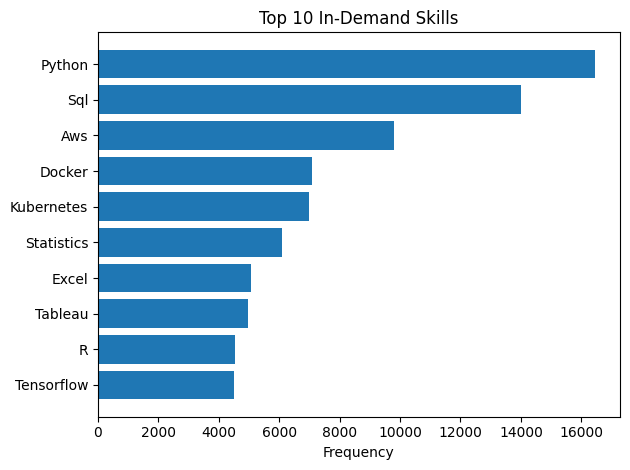

In [0]:
top = skill_demand.orderBy(col("skill_frequency").desc()).limit(10).toPandas()
plt.barh(top["skill"], top["skill_frequency"])
plt.gca().invert_yaxis(); plt.xlabel("Frequency"); plt.title("Top 10 In-Demand Skills")
plt.tight_layout(); plt.show()

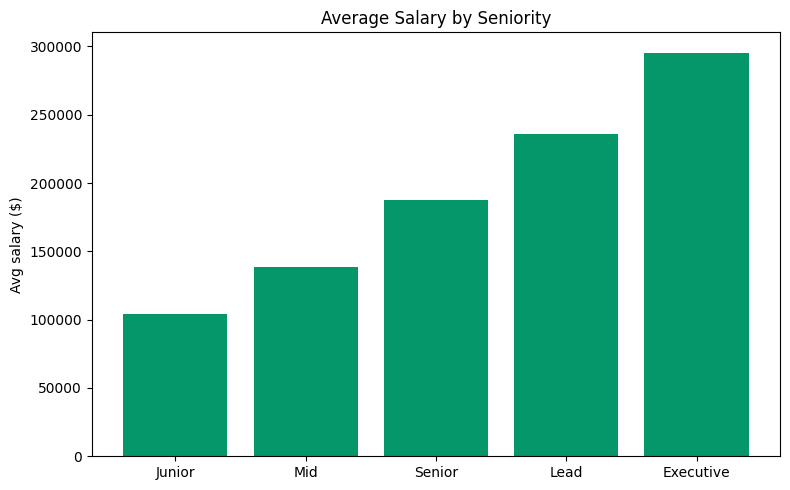

In [0]:
sen  = spark.sql("SELECT seniority, AVG((salary_min + salary_max)/2) s FROM postings GROUP BY seniority").toPandas()
wt   = spark.sql("SELECT work_type, COUNT(*) n FROM postings GROUP BY work_type ORDER BY n DESC").toPandas()
yr   = spark.sql("SELECT year, COUNT(*) p, AVG((salary_min + salary_max)/2) s FROM postings GROUP BY year ORDER BY year").toPandas()
top  = skills_long.groupBy("skill").count().orderBy(col("count").desc()).limit(10).toPandas()
pay  = (skills_long.groupBy("skill")
        .agg(sround(avg("salary_mid")).alias("avg_salary"), count("*").alias("n"))
        .filter(col("n") >= 500).orderBy(col("avg_salary").desc()).limit(10).toPandas())
samp = df_clean.select("applicant_count", "days_to_fill").sample(0.05, seed=1).toPandas()

order = ["Junior", "Mid", "Senior", "Lead", "Executive"]
sen = sen.set_index("seniority").reindex([s for s in order if s in sen["seniority"].values]).reset_index()
plt.figure(figsize=(8, 5))
plt.bar(sen["seniority"], sen["s"], color="#059669")
plt.title("Average Salary by Seniority"); plt.ylabel("Avg salary ($)")
plt.tight_layout(); plt.show()

This plot displays how the avg_salary differs across different seniority levels; Junior, Mid, Senior, Lead, and Executive highlighting which level has the highest average salary. Based on our visualization, the Executive seniority level hold the highly payed stage.

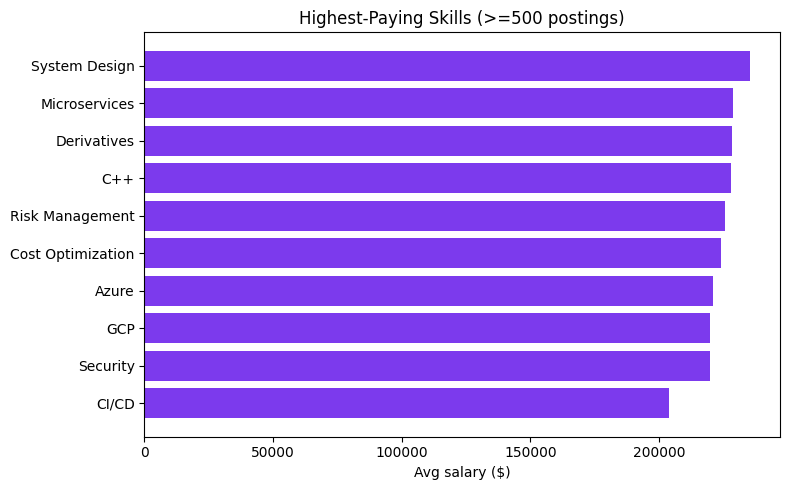

In [0]:
plt.figure(figsize=(8, 5))
plt.barh(pay["skill"], pay["avg_salary"], color="#7c3aed")
plt.gca().invert_yaxis()
plt.title("Highest-Paying Skills (>=500 postings)"); plt.xlabel("Avg salary ($)")
plt.tight_layout(); plt.show()

This chart shows the top 10 highly payed skills regarding to the highest average salaries by considering at least 500 postings from the total job lists. As we have previously described, the System Design skills hold the most payed skills. 

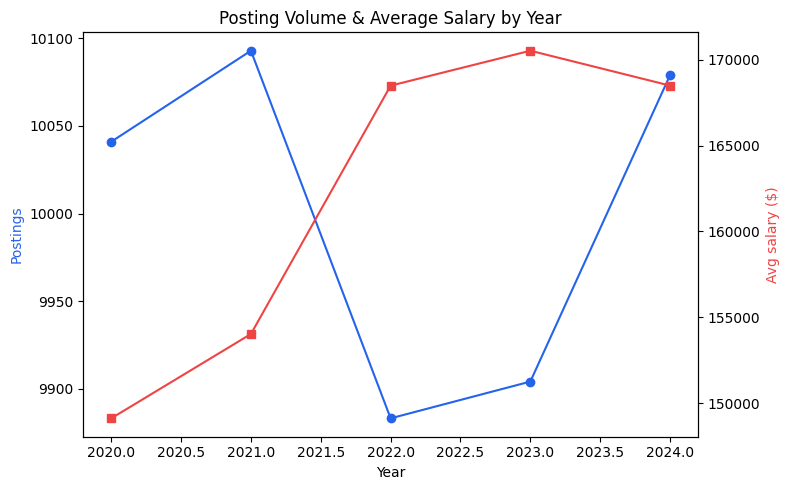

In [0]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(yr["year"], yr["p"], marker="o", color="#2563eb", label="Postings")
ax.set_xlabel("Year"); ax.set_ylabel("Postings", color="#2563eb")
ax2 = ax.twinx()
ax2.plot(yr["year"], yr["s"], marker="s", color="#ef4444", label="Avg salary")
ax2.set_ylabel("Avg salary ($)", color="#ef4444")
plt.title("Posting Volume & Average Salary by Year")
plt.tight_layout(); plt.show()

This Dual-Axis line chart uses two y-axes to show two directions; the number of job postings ( left-axis, blue line) and the avg_salary ( right-axis, red line) over the years from 2020 to 2024. This makes in understanding how both volumes and salaries have enhanced.

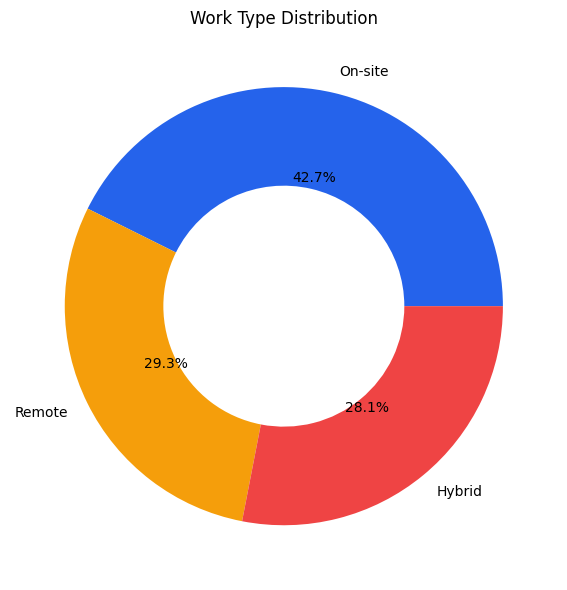

In [0]:
plt.figure(figsize=(6, 6))
plt.pie(wt["n"], labels=wt["work_type"], autopct="%1.1f%%",
        wedgeprops=dict(width=0.45), colors=["#2563eb", "#f59e0b", "#ef4444"])
plt.title("Work Type Distribution")
plt.tight_layout(); plt.show()

This pie-chart divides the different work-types ( On-site, Hybrid, Remote) among the job postings showing which job type has the highest distribution. Accordingly, the On-site work type holds almost 43% which makes it the most demanding job.

**Section 6: Results and Findings**

To sum it up we looked at 50,000 job postings from 11 industries over 4 years (2020-2024). We ensured all information was correct. Found no missing values. We fixed 3313 mistakes in work 
information. Organized 222,802 pairs of work and skill details. 

We used salary information to see career progression from Junior ($104,270) to Executive ($295,557). We found that E-commerce pays the most on average ($163,747). Finance has the most job postings 
(4623 jobs). 

When we looked at in-demand skills we found that Python is one of the wanted skills (16,457 job postings). System Design is also very important and one of the paying skills. 

Most job postings (42.6%) are for on-site jobs (21,328 jobs). Remote and Hybrid jobs are also popular 
(57.4%). We also found that non-tech jobs pay the same, as tech jobs (91% of 45,516 job postings 
have salaries). 